# Gaussian Mixture Models with Expectation-Maximization

This notebook demonstrates **soft clustering** using Gaussian Mixture Models (GMMs), trained via the **Expectation-Maximization (EM)** algorithm.

## From K-Means to GMM

K-Means assigns each point to **exactly one** cluster — a hard, binary decision. But real data is messy: points near cluster boundaries could plausibly belong to either side, and clusters aren't always nice round blobs.

**Gaussian Mixture Models** fix both problems:
- **Soft assignment:** Each point gets a *probability* of belonging to each cluster ("70% cluster A, 30% cluster B")
- **Flexible shape:** Each cluster has its own **covariance matrix**, so clusters can be elongated, tilted, or compressed — not just spherical

**The deep connection:** K-Means is actually a *special case* of GMM. If you force all covariances to be $\epsilon I$ (tiny identity matrices) and take $\epsilon \to 0$, the soft assignments collapse to hard assignments, and EM reduces to the K-Means update rule. So GMM is strictly more general.

## What We'll Cover

1. Generate data with clusters of **different shapes** (round, elongated, tilted) — where K-Means struggles
2. The multivariate Gaussian distribution — how covariance controls cluster geometry
3. Full EM algorithm from scratch — E-step (responsibilities) and M-step (parameter updates)
4. Rich visualizations: covariance ellipses, soft assignments, density contours
5. Head-to-head comparison: K-Means vs GMM on the same data

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Generate Clusters with Different Shapes

To show why GMM matters, we generate clusters that are **not** round blobs:
- **Cluster 1:** Round / isotropic (K-Means handles this fine)
- **Cluster 2:** Elongated and tilted at 45° (K-Means will split this wrong)
- **Cluster 3:** Wide and flat (horizontal ellipse)
- **Cluster 4:** Tight and small (compact cluster)

K-Means assumes all clusters are spherical and equally sized — it can only carve space with **linear Voronoi boundaries**. GMM can capture the true elliptical shapes.

In [2]:
def generate_elliptical_clusters(n_points=400, seed=42):
    """
    Generate 2D data with four clusters of deliberately different shapes.
    Returns points, true labels, and the true parameters (means, covariances).
    """
    rng = np.random.default_rng(seed)
    
    # Cluster configs: (mean, covariance, n_points)
    configs = [
        # Cluster 0: Round / isotropic
        {
            'mean': np.array([0.0, 0.0]),
            'cov': np.array([[1.0, 0.0],
                             [0.0, 1.0]]),
            'n': 100
        },
        # Cluster 1: Elongated, tilted at ~45°
        {
            'mean': np.array([5.0, 5.0]),
            'cov': np.array([[3.0, 2.2],
                             [2.2, 2.0]]),
            'n': 120
        },
        # Cluster 2: Wide and flat (horizontal ellipse)
        {
            'mean': np.array([-4.0, 4.0]),
            'cov': np.array([[4.0, 0.0],
                             [0.0, 0.3]]),
            'n': 100
        },
        # Cluster 3: Tight and small
        {
            'mean': np.array([3.0, -3.0]),
            'cov': np.array([[0.3, 0.1],
                             [0.1, 0.3]]),
            'n': 80
        }
    ]
    
    all_points = []
    all_labels = []
    true_means = []
    true_covs = []
    
    for i, cfg in enumerate(configs):
        pts = rng.multivariate_normal(cfg['mean'], cfg['cov'], size=cfg['n'])
        all_points.append(pts)
        all_labels.append(np.full(cfg['n'], i))
        true_means.append(cfg['mean'])
        true_covs.append(cfg['cov'])
    
    points = np.vstack(all_points)
    labels = np.concatenate(all_labels)
    
    # Shuffle to remove ordering
    perm = rng.permutation(len(points))
    points = points[perm]
    labels = labels[perm]
    
    return points, labels, true_means, true_covs


points, true_labels, true_means, true_covs = generate_elliptical_clusters()

K = len(true_means)  # 4 clusters

print(f"Generated {len(points)} points in {K} clusters")
print(f"Cluster sizes: {[np.sum(true_labels == i) for i in range(K)]}")
print(f"Data range: x=[{points[:,0].min():.1f}, {points[:,0].max():.1f}], "
      f"y=[{points[:,1].min():.1f}, {points[:,1].max():.1f}]")

Generated 400 points in 4 clusters
Cluster sizes: [np.int64(100), np.int64(120), np.int64(100), np.int64(80)]
Data range: x=[-9.9, 8.9], y=[-4.1, 8.2]


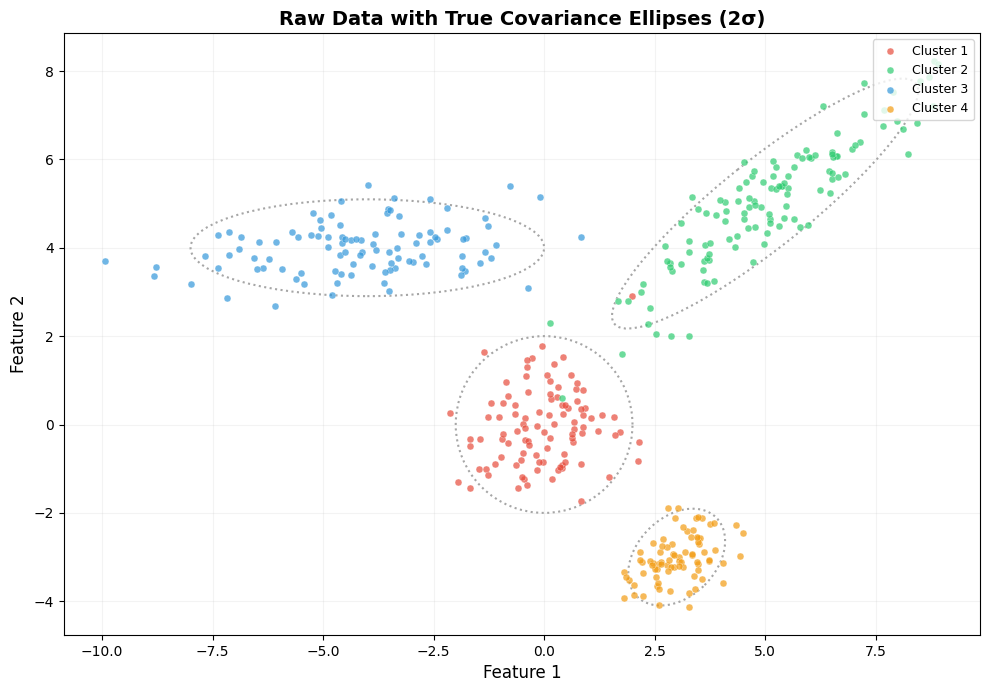

In [3]:
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']


def draw_ellipse(ax, mean, cov, color, n_std=2, **kwargs):
    """
    Draw an ellipse representing a 2D Gaussian's covariance.
    n_std controls how many standard deviations the ellipse covers.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Angle of the major axis
    angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
    # Width and height = 2 * n_std * sqrt(eigenvalue)
    width = 2 * n_std * np.sqrt(eigenvalues[1])
    height = 2 * n_std * np.sqrt(eigenvalues[0])
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, **kwargs)
    ax.add_patch(ellipse)


# Plot raw data with true covariance ellipses
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(K):
    mask = true_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=25, alpha=0.7, edgecolors='white',
               linewidths=0.3, label=f'Cluster {i+1}', zorder=5)
    
    # True covariance ellipses (dashed)
    draw_ellipse(ax, true_means[i], true_covs[i], color='gray',
                 n_std=2, fill=False, linewidth=1.5, linestyle=':', alpha=0.7)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Raw Data with True Covariance Ellipses (2\u03c3)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

## 3. The Multivariate Gaussian Distribution

The probability density of a $d$-dimensional Gaussian with mean $\mu$ and covariance $\Sigma$ is:

$$p(x \mid \mu, \Sigma) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\!\left(-\frac{1}{2}(x - \mu)^T \Sigma^{-1}(x - \mu)\right)$$

Let's unpack each piece:

| Symbol | Name | Role |
|--------|------|------|
| $\mu$ | Mean vector | Center of the cluster |
| $\Sigma$ | Covariance matrix | Controls shape, size, and orientation |
| $|\Sigma|$ | Determinant | Measures the "volume" of the ellipse — larger = more spread |
| $(x-\mu)^T \Sigma^{-1}(x-\mu)$ | **Mahalanobis distance** squared | How far $x$ is from $\mu$, adjusted for the cluster's shape |

### How covariance controls shape

The covariance matrix $\Sigma$ is symmetric positive-definite, so it has an **eigendecomposition** $\Sigma = V \Lambda V^T$ where:
- **Eigenvectors** $V$ = principal axes (orientation/tilt of the ellipse)
- **Eigenvalues** $\Lambda$ = variance along each axis (how stretched the ellipse is)

Three cases:
- $\Sigma = \sigma^2 I$ → **circle** (isotropic, same spread in all directions)
- $\Sigma$ diagonal, unequal entries → **axis-aligned ellipse** (stretched along coordinate axes)
- $\Sigma$ with off-diagonal entries → **rotated ellipse** (tilted by the eigenvector angles)

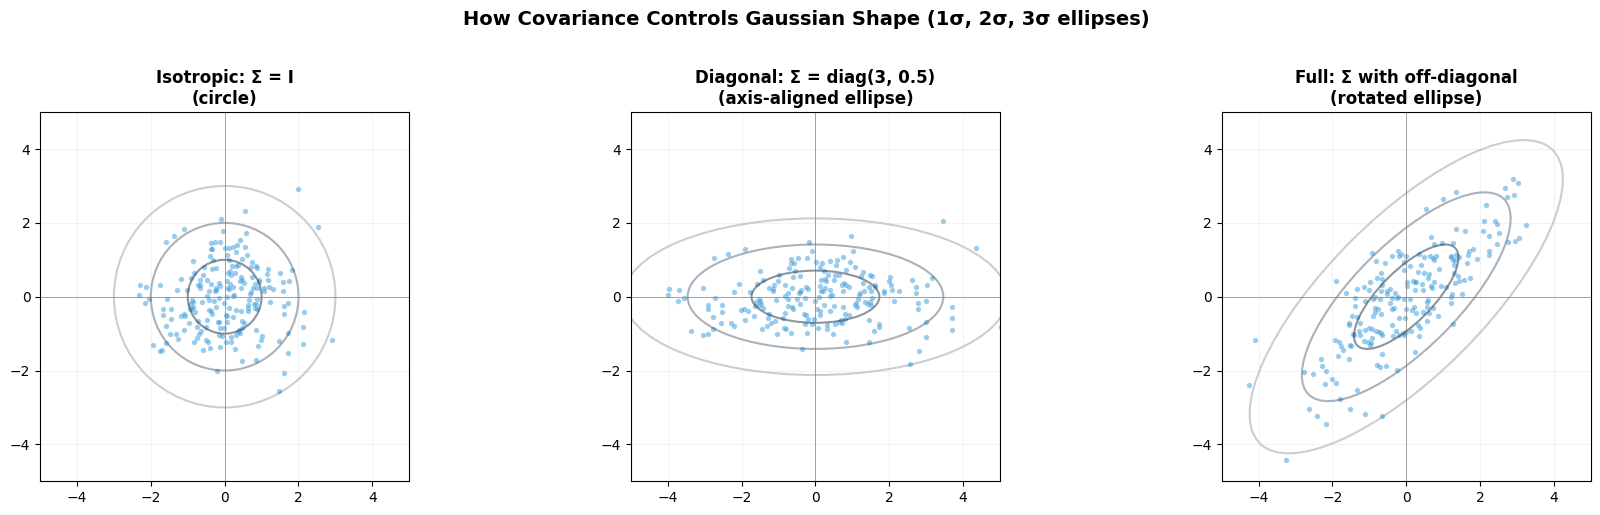

In [4]:
# Visualize how covariance controls shape
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

example_covs = [
    (np.array([[1, 0], [0, 1]]), 'Isotropic: \u03a3 = I\n(circle)'),
    (np.array([[3, 0], [0, 0.5]]), 'Diagonal: \u03a3 = diag(3, 0.5)\n(axis-aligned ellipse)'),
    (np.array([[2, 1.5], [1.5, 2]]), 'Full: \u03a3 with off-diagonal\n(rotated ellipse)')
]

for ax, (cov, title) in zip(axes, example_covs):
    rng_ex = np.random.default_rng(42)
    samples = rng_ex.multivariate_normal([0, 0], cov, size=200)
    
    ax.scatter(samples[:, 0], samples[:, 1], s=15, alpha=0.5, c='#3498db',
               edgecolors='white', linewidths=0.2)
    
    for n_std in [1, 2, 3]:
        draw_ellipse(ax, [0, 0], cov, color='#2c3e50', n_std=n_std,
                     fill=False, linewidth=1.5, alpha=0.7 - n_std*0.15)
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.15)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('How Covariance Controls Gaussian Shape (1\u03c3, 2\u03c3, 3\u03c3 ellipses)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. The EM Algorithm for Gaussian Mixture Models

A GMM models the data as a weighted sum of $K$ Gaussian components:

$$p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

where $\pi_k$ are **mixing weights** ($\sum_k \pi_k = 1$) — the prior probability that a random point belongs to component $k$.

EM alternates between two steps:

### E-step (Expectation): Compute Responsibilities

For each point $x_n$ and component $k$, compute the **responsibility** — the posterior probability that component $k$ generated $x_n$:

$$r_{nk} = \frac{\pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \, \mathcal{N}(x_n \mid \mu_j, \Sigma_j)}$$

This is just Bayes' theorem: prior ($\pi_k$) times likelihood ($\mathcal{N}$), normalized.

### M-step (Maximization): Update Parameters

Using the soft assignments, update each component's parameters:

$$N_k = \sum_{n=1}^N r_{nk} \quad \text{(effective number of points in cluster } k\text{)}$$

$$\mu_k = \frac{1}{N_k} \sum_{n=1}^N r_{nk} \, x_n \quad \text{(weighted mean)}$$

$$\Sigma_k = \frac{1}{N_k} \sum_{n=1}^N r_{nk} \, (x_n - \mu_k)(x_n - \mu_k)^T \quad \text{(weighted covariance)}$$

$$\pi_k = \frac{N_k}{N} \quad \text{(updated mixing weight)}$$

### Log-Likelihood

EM maximizes the log-likelihood, which **provably increases** at every iteration:

$$\mathcal{L} = \sum_{n=1}^N \log \sum_{k=1}^K \pi_k \, \mathcal{N}(x_n \mid \mu_k, \Sigma_k)$$

### Numerical Stability: The Log-Sum-Exp Trick

The Gaussian density involves $\exp(-\frac{1}{2} \text{Mahalanobis}^2)$, which can underflow to zero for distant points. We work in log-space and use the identity:

$$\log \sum_k e^{a_k} = \max(a) + \log \sum_k e^{a_k - \max(a)}$$

This shifts the exponents so the largest is 0, preventing overflow/underflow.

In [5]:
def log_gaussian_pdf(x, mu, sigma):
    """
    Compute log N(x | mu, sigma) for each point.
    
    x: (N, d) array of points
    mu: (d,) mean vector
    sigma: (d, d) covariance matrix
    
    Returns: (N,) array of log-densities
    """
    d = len(mu)
    diff = x - mu  # (N, d)
    
    # Cholesky for numerical stability and efficient computation
    try:
        L = np.linalg.cholesky(sigma)
    except np.linalg.LinAlgError:
        # Add regularization if not positive-definite
        L = np.linalg.cholesky(sigma + 1e-6 * np.eye(d))
    
    # Solve L * z = diff^T for each point → z = L^{-1} diff^T
    z = np.linalg.solve(L, diff.T)  # (d, N)
    
    # Mahalanobis squared = ||z||^2 for each point
    mahal_sq = np.sum(z**2, axis=0)  # (N,)
    
    # Log determinant = 2 * sum(log(diag(L)))
    log_det = 2 * np.sum(np.log(np.diag(L)))
    
    # log N(x|mu,sigma) = -d/2 log(2pi) - 1/2 log|sigma| - 1/2 mahal^2
    log_prob = -0.5 * (d * np.log(2 * np.pi) + log_det + mahal_sq)
    
    return log_prob


def log_sum_exp(log_vals, axis=None):
    """Numerically stable log-sum-exp."""
    max_val = np.max(log_vals, axis=axis, keepdims=True)
    return np.squeeze(max_val, axis=axis) + np.log(
        np.sum(np.exp(log_vals - max_val), axis=axis)
    )


def em_gmm(points, k, max_iter=200, tol=1e-6, seed=123):
    """
    Expectation-Maximization for Gaussian Mixture Models.
    
    Parameters:
    -----------
    points : (N, d) array
    k : number of components
    max_iter : maximum iterations
    tol : convergence threshold on log-likelihood change
    seed : random seed for initialization
    
    Returns:
    --------
    labels : (N,) hard assignments (argmax of responsibilities)
    responsibilities : (N, k) soft assignments
    means : (k, d) estimated means
    covariances : list of (d, d) estimated covariance matrices
    weights : (k,) mixing weights
    ll_history : list of log-likelihoods per iteration
    """
    rng = np.random.default_rng(seed)
    N, d = points.shape
    
    # --- Initialization ---
    # Pick k random data points as initial means
    init_idx = rng.choice(N, size=k, replace=False)
    means = points[init_idx].copy()
    
    # Initialize covariances as identity matrices
    covariances = [np.eye(d) for _ in range(k)]
    
    # Equal mixing weights
    weights = np.ones(k) / k
    
    ll_history = []
    reg = 1e-6  # Regularization to prevent singular covariances
    
    for iteration in range(max_iter):
        # === E-step: compute responsibilities ===
        log_resp = np.zeros((N, k))
        for j in range(k):
            log_resp[:, j] = np.log(weights[j]) + log_gaussian_pdf(
                points, means[j], covariances[j]
            )
        
        # Normalize (log-sum-exp trick)
        log_resp_norm = log_sum_exp(log_resp, axis=1)  # (N,)
        log_resp_normalized = log_resp - log_resp_norm[:, np.newaxis]
        responsibilities = np.exp(log_resp_normalized)
        
        # Log-likelihood
        ll = np.sum(log_resp_norm)
        ll_history.append(ll)
        
        # Check convergence
        if iteration > 0 and abs(ll - ll_history[-2]) < tol:
            print(f"Converged at iteration {iteration + 1}")
            break
        
        # === M-step: update parameters ===
        for j in range(k):
            r_j = responsibilities[:, j]  # (N,)
            N_j = np.sum(r_j)
            
            if N_j < 1e-10:
                # Dead component — reinitialize
                means[j] = points[rng.choice(N)]
                covariances[j] = np.eye(d)
                weights[j] = 1.0 / k
                continue
            
            # Updated mean
            means[j] = np.sum(r_j[:, np.newaxis] * points, axis=0) / N_j
            
            # Updated covariance
            diff = points - means[j]  # (N, d)
            covariances[j] = (diff.T @ (diff * r_j[:, np.newaxis])) / N_j
            covariances[j] += reg * np.eye(d)  # regularization
            
            # Updated mixing weight
            weights[j] = N_j / N
    else:
        print(f"Reached max iterations ({max_iter})")
    
    labels = np.argmax(responsibilities, axis=1)
    
    return labels, responsibilities, means, covariances, weights, ll_history


# Run EM
gmm_labels, gmm_resp, gmm_means, gmm_covs, gmm_weights, gmm_ll = em_gmm(
    points, k=K, max_iter=200
)

print(f"\nCluster sizes: {[np.sum(gmm_labels == i) for i in range(K)]}")
print(f"Mixing weights: {[f'{w:.3f}' for w in gmm_weights]}")
print(f"Final log-likelihood: {gmm_ll[-1]:.2f}")

Reached max iterations (200)

Cluster sizes: [np.int64(58), np.int64(119), np.int64(42), np.int64(181)]
Mixing weights: ['0.129', '0.303', '0.119', '0.449']
Final log-likelihood: -1674.40


## 5. Visualizations

### 5a. GMM Clustering with Covariance Ellipses

Each component's learned covariance is shown as solid ellipses (1\u03c3, 2\u03c3). Compare them to the true covariances (dotted gray) — the closer the match, the better EM has recovered the true generative model.

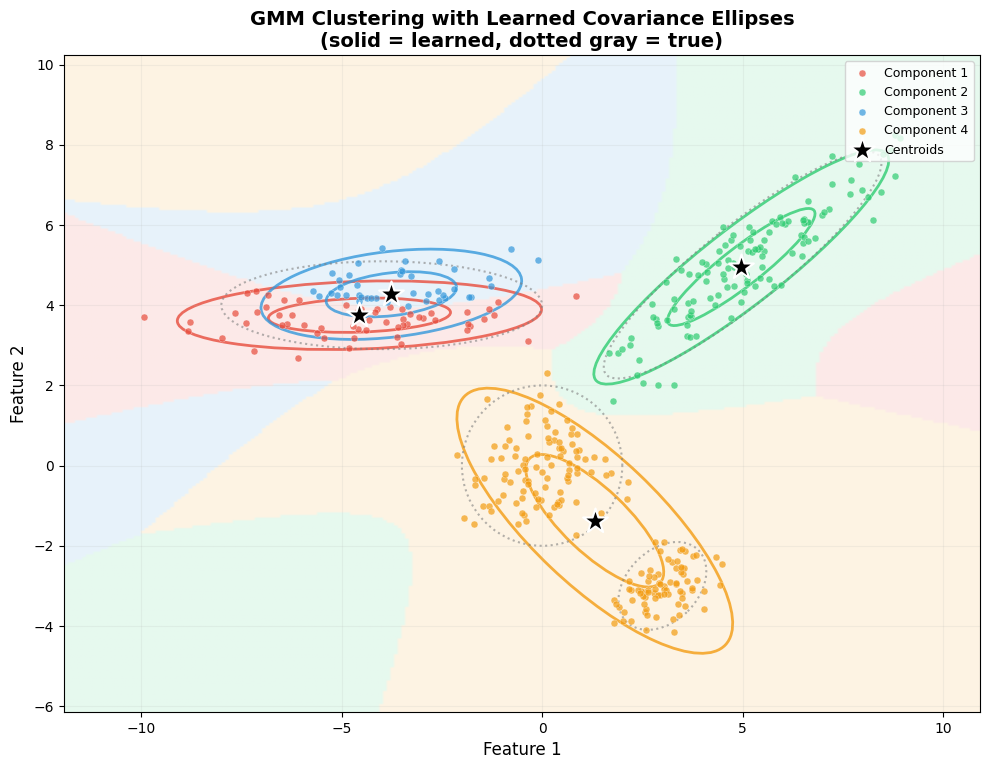

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# Background: soft Voronoi shading using GMM posterior
grid_res = 250
x_min, x_max = points[:, 0].min() - 2, points[:, 0].max() + 2
y_min, y_max = points[:, 1].min() - 2, points[:, 1].max() + 2
gx = np.linspace(x_min, x_max, grid_res)
gy = np.linspace(y_min, y_max, grid_res)
gx_mesh, gy_mesh = np.meshgrid(gx, gy)
grid_pts = np.stack([gx_mesh.ravel(), gy_mesh.ravel()], axis=-1)

# Compute responsibilities for grid points
log_resp_grid = np.zeros((len(grid_pts), K))
for j in range(K):
    log_resp_grid[:, j] = np.log(gmm_weights[j]) + log_gaussian_pdf(
        grid_pts, gmm_means[j], gmm_covs[j]
    )
grid_labels = np.argmax(log_resp_grid, axis=1)
grid_img = grid_labels.reshape(grid_res, grid_res)

# Background shading
bg_rgba = np.ones((grid_res, grid_res, 4))
for i in range(K):
    mask_2d = grid_img == i
    bg_rgba[mask_2d] = mcolors.to_rgba(cluster_colors[i], alpha=0.12)

ax.imshow(bg_rgba, extent=[x_min, x_max, y_min, y_max],
          origin='lower', aspect='equal')

# Plot points colored by GMM assignment
for i in range(K):
    mask = gmm_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=25, alpha=0.7, edgecolors='white',
               linewidths=0.3, label=f'Component {i+1}', zorder=5)

# Learned covariance ellipses (solid)
for i in range(K):
    for n_std in [1, 2]:
        draw_ellipse(ax, gmm_means[i], gmm_covs[i], color=cluster_colors[i],
                     n_std=n_std, fill=False, linewidth=2, alpha=0.8)

# True covariance ellipses (dotted gray) for comparison
for i in range(K):
    draw_ellipse(ax, true_means[i], true_covs[i], color='gray',
                 n_std=2, fill=False, linewidth=1.5, linestyle=':', alpha=0.6)

# Centroids
ax.scatter(gmm_means[:, 0], gmm_means[:, 1],
           c='black', marker='*', s=350, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('GMM Clustering with Learned Covariance Ellipses\n'
             '(solid = learned, dotted gray = true)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

### 5b. Soft Assignment Visualization

Unlike K-Means, GMM gives each point a **probability distribution** over clusters. Points deep inside a cluster have near-100% confidence; points near boundaries are uncertain. We show this by varying point opacity with the maximum responsibility.

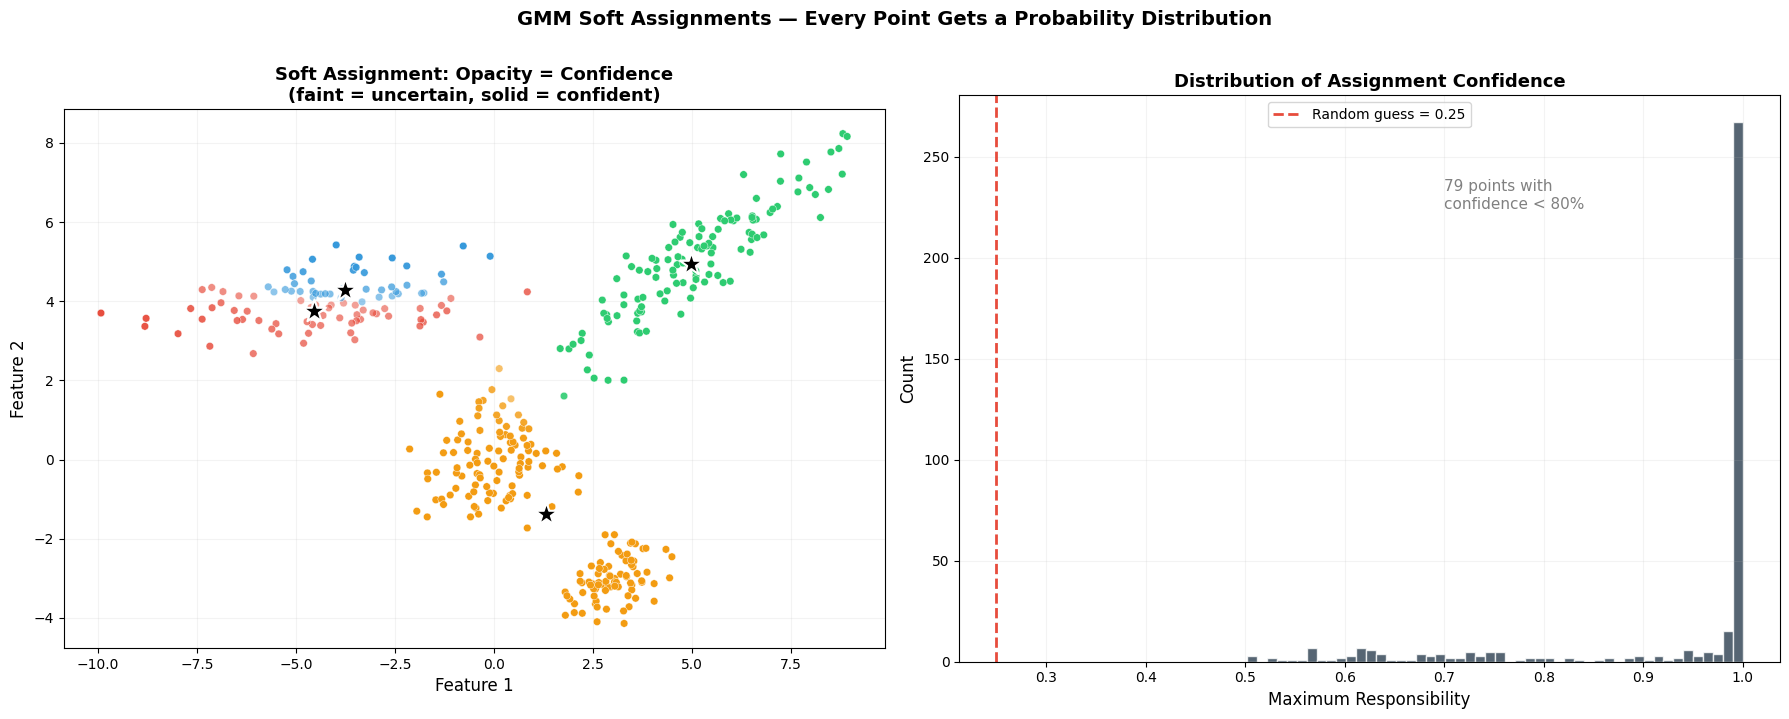

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: colored by assignment, alpha by confidence
ax = axes[0]
max_resp = np.max(gmm_resp, axis=1)
for i in range(K):
    mask = gmm_labels == i
    rgba = mcolors.to_rgba(cluster_colors[i])
    colors_arr = np.tile(rgba, (np.sum(mask), 1))
    colors_arr[:, 3] = max_resp[mask]  # alpha = confidence
    ax.scatter(points[mask, 0], points[mask, 1],
               c=colors_arr, s=30, edgecolors='white',
               linewidths=0.3, zorder=5)

ax.scatter(gmm_means[:, 0], gmm_means[:, 1],
           c='black', marker='*', s=300, edgecolors='white',
           linewidths=1.5, zorder=10)
ax.set_title('Soft Assignment: Opacity = Confidence\n(faint = uncertain, solid = confident)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)

# Right: histogram of max responsibilities
ax = axes[1]
ax.hist(max_resp, bins=50, color='#2c3e50', edgecolor='white', alpha=0.8)
ax.axvline(1.0 / K, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Random guess = {1/K:.2f}')
ax.set_xlabel('Maximum Responsibility', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Assignment Confidence',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)

n_uncertain = np.sum(max_resp < 0.8)
ax.annotate(f'{n_uncertain} points with\nconfidence < 80%',
            xy=(0.7, ax.get_ylim()[1] * 0.8), fontsize=11, color='gray')

plt.suptitle('GMM Soft Assignments — Every Point Gets a Probability Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5c. Convergence Plot

A key property of EM: the log-likelihood is **guaranteed to increase** (or stay the same) at every iteration. If it ever decreases, there's a bug.

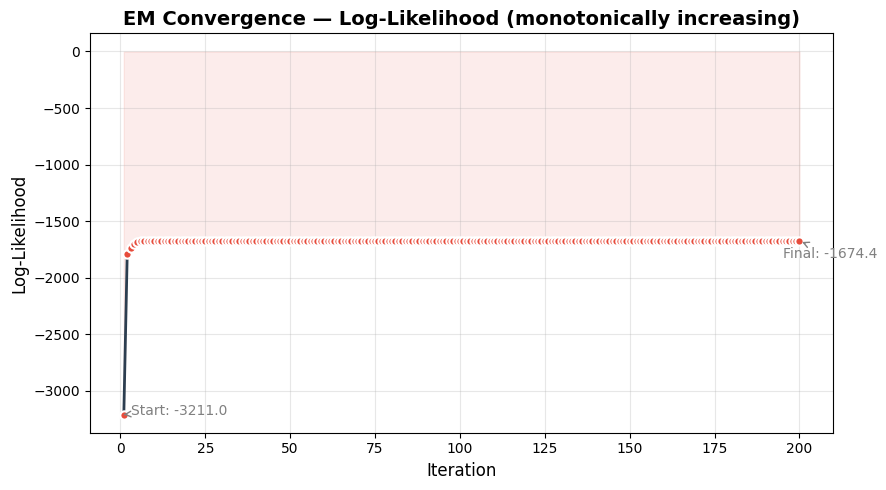

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

iterations = range(1, len(gmm_ll) + 1)

ax.plot(iterations, gmm_ll, 'o-', color='#2c3e50', markersize=6,
        linewidth=2, markerfacecolor='#e74c3c', markeredgecolor='white',
        markeredgewidth=1.5)

ax.fill_between(iterations, gmm_ll, alpha=0.1, color='#e74c3c')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Log-Likelihood', fontsize=12)
ax.set_title('EM Convergence — Log-Likelihood (monotonically increasing)',
             fontsize=14, fontweight='bold')

ax.annotate(f'Start: {gmm_ll[0]:.1f}', xy=(1, gmm_ll[0]),
            xytext=(3, gmm_ll[0]),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')
ax.annotate(f'Final: {gmm_ll[-1]:.1f}', xy=(len(gmm_ll), gmm_ll[-1]),
            xytext=(max(1, len(gmm_ll) - 5), gmm_ll[-1] - (gmm_ll[-1] - gmm_ll[0]) * 0.1),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5d. Mixture Density Contour Plot

The full GMM density $p(x) = \sum_k \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$ is a smooth surface over 2D space. Contour lines show regions of equal probability — notice how they naturally follow the elongated and tilted cluster shapes.

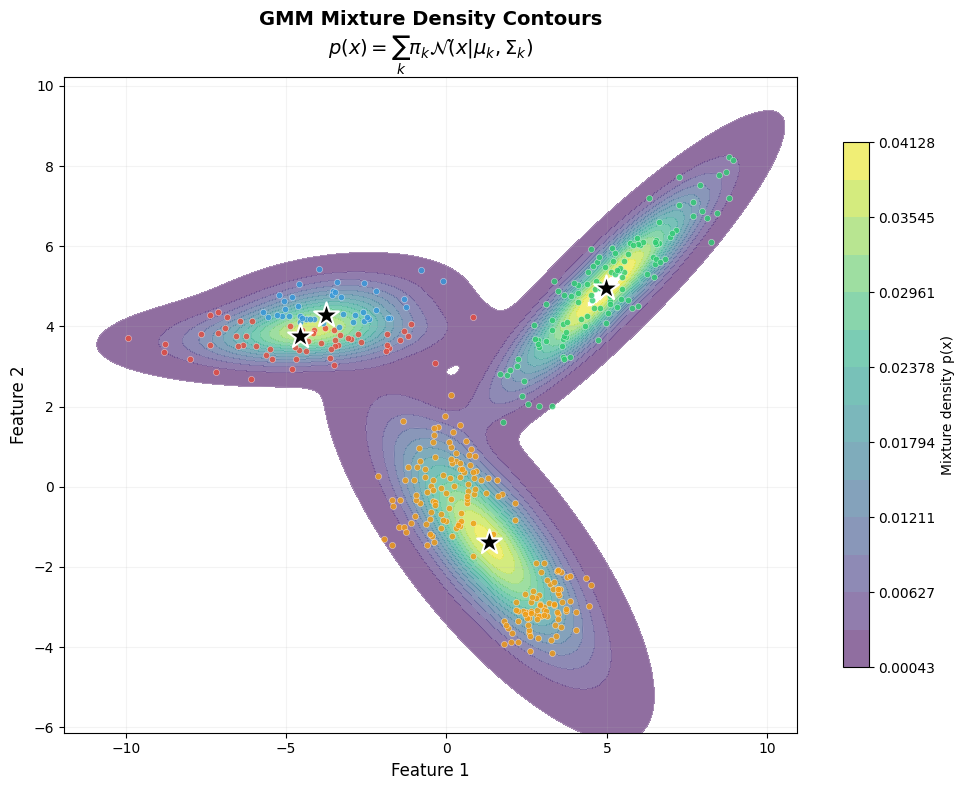

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Compute mixture density on grid
log_density = np.full(len(grid_pts), -np.inf)
log_components = np.zeros((len(grid_pts), K))
for j in range(K):
    log_components[:, j] = np.log(gmm_weights[j]) + log_gaussian_pdf(
        grid_pts, gmm_means[j], gmm_covs[j]
    )
log_density = log_sum_exp(log_components, axis=1)
density = np.exp(log_density).reshape(grid_res, grid_res)

# Contour plot
levels = np.linspace(density.max() * 0.01, density.max() * 0.95, 15)
contour = ax.contourf(gx_mesh, gy_mesh, density, levels=levels,
                       cmap='viridis', alpha=0.6)
ax.contour(gx_mesh, gy_mesh, density, levels=levels,
           colors='white', linewidths=0.3, alpha=0.5)

# Overlay points
for i in range(K):
    mask = gmm_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=20, alpha=0.8, edgecolors='white',
               linewidths=0.3, zorder=5)

ax.scatter(gmm_means[:, 0], gmm_means[:, 1],
           c='black', marker='*', s=350, edgecolors='white',
           linewidths=1.5, zorder=10)

plt.colorbar(contour, ax=ax, label='Mixture density p(x)', shrink=0.8)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('GMM Mixture Density Contours\n'
             r'$p(x) = \sum_k \pi_k \mathcal{N}(x|\mu_k, \Sigma_k)$',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

---
## 6. K-Means vs GMM — Head-to-Head Comparison

Let's run standard Euclidean K-Means on the same data and see where the two methods disagree. The key difference: K-Means carves space with **straight lines** (Voronoi boundaries), while GMM uses **curved** boundaries shaped by each cluster's covariance.

In [10]:
def euclidean_kmeans(points, k=4, max_iter=100, tol=1e-6, seed=123):
    """Standard Euclidean K-means for comparison."""
    rng = np.random.default_rng(seed)
    n = len(points)
    
    init_idx = rng.choice(n, size=k, replace=False)
    centroids = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        dist_matrix = np.zeros((n, k))
        for j in range(k):
            dist_matrix[:, j] = np.linalg.norm(points - centroids[j], axis=1)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = np.sum(dist_matrix[np.arange(n), labels]**2)
        history.append(total_dist)
        
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centroids[j] = points[rng.choice(n)]
            else:
                new_centroids[j] = members.mean(axis=0)
        
        shift = np.max(np.linalg.norm(centroids - new_centroids, axis=1))
        centroids = new_centroids
        
        if shift < tol:
            print(f"K-Means converged at iteration {iteration + 1}")
            break
    else:
        print(f"K-Means reached max iterations ({max_iter})")
    
    return labels, centroids, history


km_labels, km_centroids, km_history = euclidean_kmeans(points, k=K)

print(f"K-Means cluster sizes: {[np.sum(km_labels == i) for i in range(K)]}")
print(f"GMM cluster sizes:     {[np.sum(gmm_labels == i) for i in range(K)]}")

K-Means converged at iteration 10
K-Means cluster sizes: [np.int64(52), np.int64(114), np.int64(57), np.int64(177)]
GMM cluster sizes:     [np.int64(58), np.int64(119), np.int64(42), np.int64(181)]


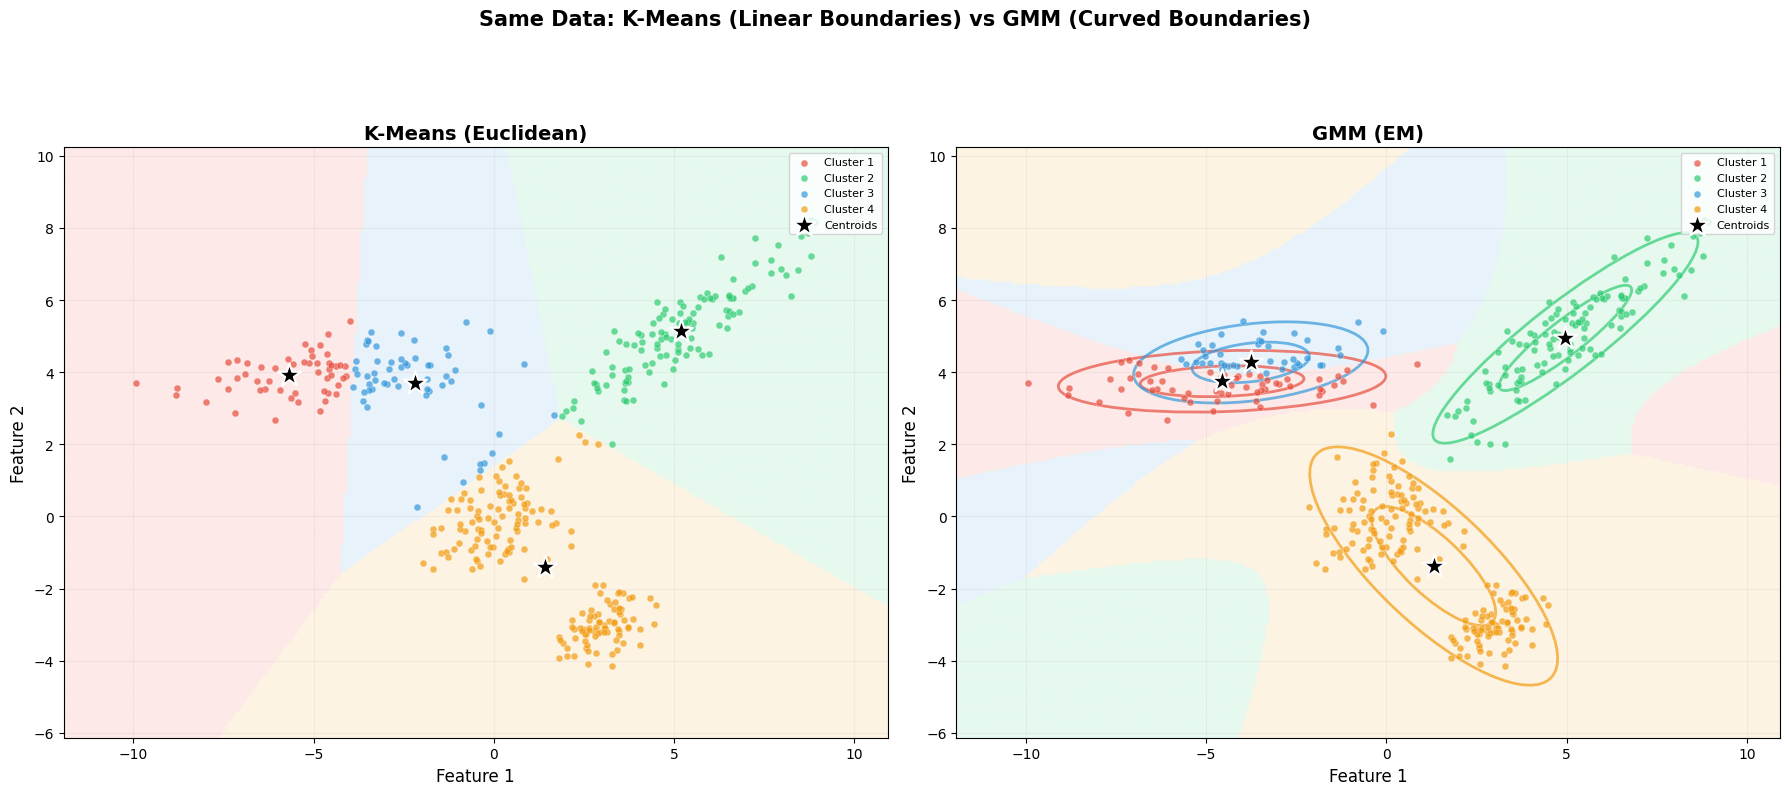

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

configs = [
    ('K-Means (Euclidean)', km_labels, km_centroids, None),
    ('GMM (EM)', gmm_labels, gmm_means, gmm_covs)
]

for ax, (title, lbls, cents, covs) in zip(axes, configs):
    # Background shading
    if covs is None:
        # K-Means: Voronoi by Euclidean distance
        grid_dists = np.zeros((len(grid_pts), K))
        for j in range(K):
            grid_dists[:, j] = np.linalg.norm(grid_pts - cents[j], axis=1)
        bg_labels = np.argmin(grid_dists, axis=1)
    else:
        # GMM: by posterior probability
        log_r = np.zeros((len(grid_pts), K))
        for j in range(K):
            log_r[:, j] = np.log(gmm_weights[j]) + log_gaussian_pdf(
                grid_pts, cents[j], covs[j]
            )
        bg_labels = np.argmax(log_r, axis=1)
    
    bg_img = bg_labels.reshape(grid_res, grid_res)
    bg_rgba = np.ones((grid_res, grid_res, 4))
    for i in range(K):
        mask_2d = bg_img == i
        bg_rgba[mask_2d] = mcolors.to_rgba(cluster_colors[i], alpha=0.12)
    ax.imshow(bg_rgba, extent=[x_min, x_max, y_min, y_max],
              origin='lower', aspect='equal')
    
    # Points
    for i in range(K):
        mask = lbls == i
        ax.scatter(points[mask, 0], points[mask, 1],
                   c=cluster_colors[i], s=25, alpha=0.7, edgecolors='white',
                   linewidths=0.3, label=f'Cluster {i+1}', zorder=5)
    
    # Centroids
    ax.scatter(cents[:, 0], cents[:, 1],
               c='black', marker='*', s=300, edgecolors='white',
               linewidths=1.5, zorder=10, label='Centroids')
    
    # Covariance ellipses for GMM
    if covs is not None:
        for i in range(K):
            for n_std in [1, 2]:
                draw_ellipse(ax, cents[i], covs[i], color=cluster_colors[i],
                             n_std=n_std, fill=False, linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.15)

plt.suptitle('Same Data: K-Means (Linear Boundaries) vs GMM (Curved Boundaries)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6b. Disagreement Analysis — Where K-Means Fails

Let's quantify and visualize which points the two methods assign differently. The disagreements concentrate around elongated / tilted clusters, where K-Means' assumption of spherical clusters breaks down.

Rand Index (agreement with ground truth):
  K-Means  vs True: 0.8394
  GMM (EM) vs True: 0.8601
  K-Means  vs GMM:  0.9308



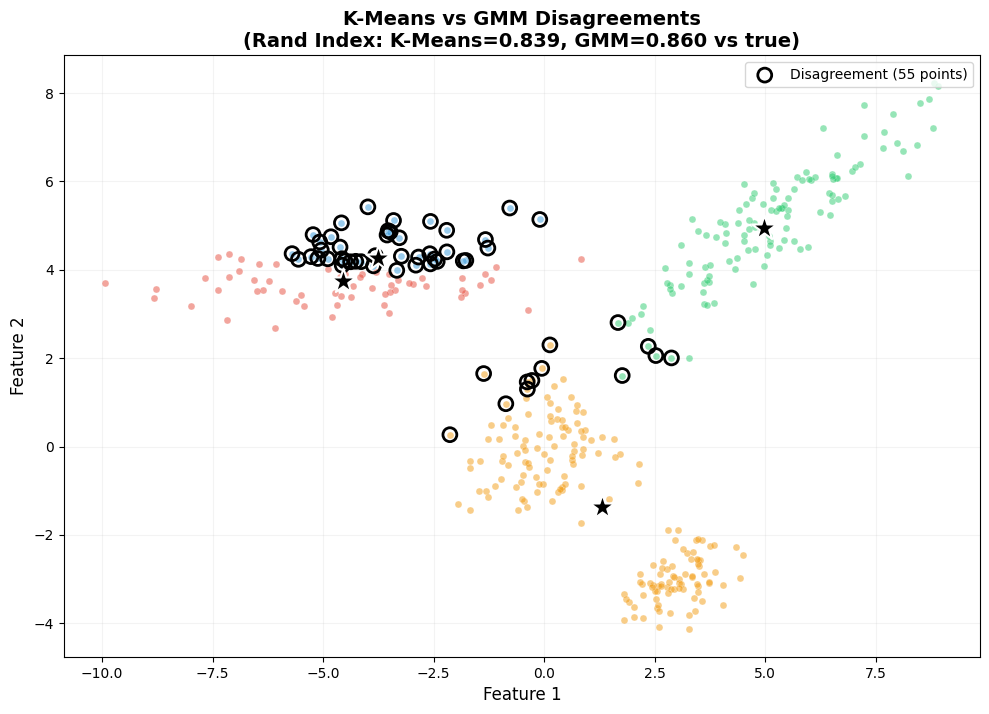

In [12]:
from itertools import combinations


def rand_index(labels_a, labels_b):
    """Compute the Rand Index between two clusterings."""
    n = len(labels_a)
    agree = 0
    total = 0
    for i, j in combinations(range(n), 2):
        same_a = labels_a[i] == labels_a[j]
        same_b = labels_b[i] == labels_b[j]
        if same_a == same_b:
            agree += 1
        total += 1
    return agree / total if total > 0 else 1.0


# Compute agreement metrics
ri_km_true = rand_index(km_labels, true_labels)
ri_gmm_true = rand_index(gmm_labels, true_labels)
ri_km_gmm = rand_index(km_labels, gmm_labels)

print("Rand Index (agreement with ground truth):")
print(f"  K-Means  vs True: {ri_km_true:.4f}")
print(f"  GMM (EM) vs True: {ri_gmm_true:.4f}")
print(f"  K-Means  vs GMM:  {ri_km_gmm:.4f}")
print()

# Visualize disagreement
fig, ax = plt.subplots(figsize=(10, 8))

# Find points where K-Means and GMM assignments match vs differ
# (We compare same-cluster membership since label indices may differ)
agree_mask = np.array([
    (km_labels[i] == km_labels[j]) == (gmm_labels[i] == gmm_labels[j])
    for i in range(len(points))
    for j in range(i + 1, min(i + 2, len(points)))
])

# Simpler: color points by GMM assignment, highlight where K-Means disagrees
# Find points that are in different clusters according to k-means vs gmm
# by checking if pairs are split differently
for i in range(K):
    mask = gmm_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=25, alpha=0.5, edgecolors='white',
               linewidths=0.3, zorder=3)

# Highlight points where the two methods disagree on cluster assignment
# (note: label indices may not match, so we use a matching approach)
# Build a mapping from K-Means labels to GMM labels using majority vote
km_to_gmm = {}
for km_lbl in range(K):
    mask = km_labels == km_lbl
    if np.any(mask):
        # Which GMM label is most common among points K-Means assigned to this cluster?
        gmm_for_these = gmm_labels[mask]
        counts = np.bincount(gmm_for_these, minlength=K)
        km_to_gmm[km_lbl] = np.argmax(counts)

# Points where the mapped K-Means label != GMM label
mapped_km = np.array([km_to_gmm.get(l, -1) for l in km_labels])
disagree = mapped_km != gmm_labels

ax.scatter(points[disagree, 0], points[disagree, 1],
           facecolors='none', edgecolors='black', s=100, linewidths=2,
           label=f'Disagreement ({np.sum(disagree)} points)', zorder=8)

# Centroids
ax.scatter(gmm_means[:, 0], gmm_means[:, 1],
           c='black', marker='*', s=350, edgecolors='white',
           linewidths=1.5, zorder=10)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title(f'K-Means vs GMM Disagreements\n'
             f'(Rand Index: K-Means={ri_km_true:.3f}, GMM={ri_gmm_true:.3f} vs true)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

### 6c. Accuracy Comparison

Bar chart comparing Rand Index against the ground truth.

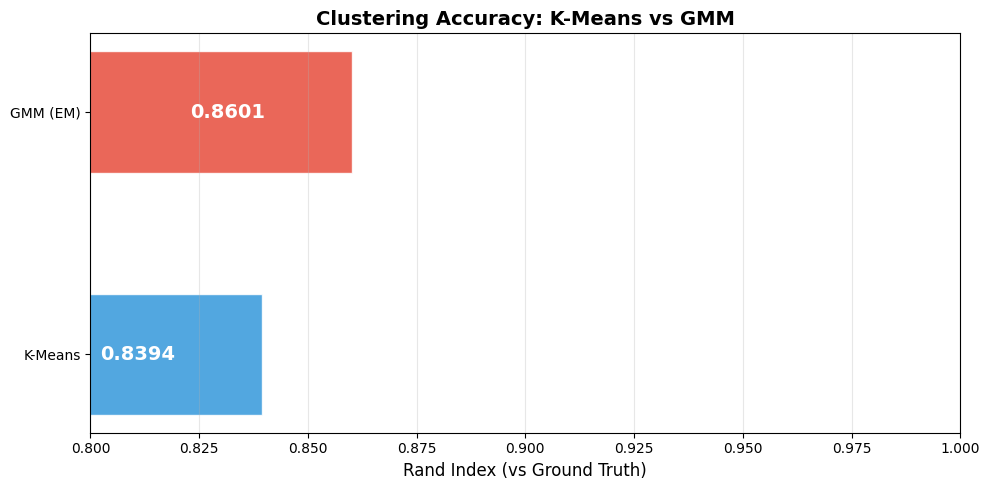

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

methods = ['K-Means', 'GMM (EM)']
scores = [ri_km_true, ri_gmm_true]
bar_colors = ['#3498db', '#e74c3c']

bars = ax.barh(methods, scores, color=bar_colors, edgecolor='white',
               height=0.5, alpha=0.85)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', ha='right', fontsize=14,
            fontweight='bold', color='white')

ax.set_xlabel('Rand Index (vs Ground Truth)', fontsize=12)
ax.set_title('Clustering Accuracy: K-Means vs GMM',
             fontsize=14, fontweight='bold')
ax.set_xlim(0.8, 1.0)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# For GMM, use hard assignments (argmax of responsibilities) for TWCSS and silhouette.
# em_gmm() is already defined above.
# Note: this notebook uses K=4 components; the elbow/silhouette will confirm that choice.

# Build full N×N Euclidean pairwise distance matrix
n_pts = len(points)
print("Building pairwise Euclidean distance matrix...")
D_full = np.zeros((n_pts, n_pts))
for i in range(n_pts):
    D_full[i] = np.linalg.norm(points - points[i], axis=1)

# TWCSS baseline: one cluster, centred on the global mean
overall_center = points.mean(axis=0)
TWCSS_1 = float(np.sum(np.linalg.norm(points - overall_center, axis=1) ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

K_chosen = 4  # this notebook's chosen K (elliptical clusters)

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, _, means_k, _, _, _ = em_gmm(points, k=k, max_iter=200)
    dists_k = np.linalg.norm(points - means_k[lbls_k], axis=1)
    twcss_k = float(np.sum(dists_k ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_full, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen_gmm = 4  # chosen K for this notebook
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen_gmm, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen_gmm}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen_gmm, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen_gmm}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation (Euclidean GMM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen_gmm else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

---
## 7. Summary

| Aspect | K-Means | GMM (EM) |
|--------|---------|----------|
| **Assignment** | Hard (0 or 1) | Soft (probabilities $r_{nk} \in [0, 1]$) |
| **Cluster shape** | Spherical only (Voronoi cells) | Any elliptical shape (full covariance) |
| **Parameters per cluster** | Mean only ($\mu_k$) | Mean ($\mu_k$) + Covariance ($\Sigma_k$) + Weight ($\pi_k$) |
| **Objective** | Minimize total squared distance | Maximize log-likelihood |
| **Decision boundary** | Linear (hyperplanes) | Curved (quadratic) |
| **Handles varying density** | No — equal-volume Voronoi cells | Yes — via mixing weights $\pi_k$ |
| **Handles varying shape** | No — always spherical | Yes — via per-cluster $\Sigma_k$ |
| **Convergence guarantee** | Monotonically decreasing cost | Monotonically increasing log-likelihood |
| **Speed** | Fast | Slower (matrix inversions per step) |
| **Best for** | Quick baseline, well-separated round clusters | Overlapping, non-spherical, varying-density clusters |

### Key Takeaways

1. **GMM is strictly more general than K-Means.** K-Means is the special case where all covariances are $\epsilon I$ and $\epsilon \to 0$. Any data where K-Means works well, GMM will also work well — but GMM handles more complex cluster geometries.

2. **Soft assignments are genuinely useful.** Points near cluster boundaries get split responsibilities, which gives you a built-in uncertainty measure. In K-Means, a point 0.001 closer to centroid A than B gets assigned to A with 100% confidence — GMM would say "51% A, 49% B."

3. **The covariance ellipses are the key visual.** If your data has elongated, tilted, or differently-sized clusters, the covariance ellipses will show that GMM captures this while K-Means' implied "equal spheres" assumption breaks down.

4. **Watch out for initialization.** Both methods are sensitive to initialization. GMM can converge to poor local optima, especially with many components. Multiple restarts help.

### Next: Spherical — von Mises-Fisher Mixture

On a sphere, the Gaussian distribution doesn't apply — you can't have a symmetric bell curve on a curved surface. The **von Mises-Fisher (vMF) distribution** is the natural "Gaussian of the sphere," parameterized by a mean direction $\mu$ and concentration $\kappa$ (analogous to $1/\sigma^2$). In the next notebook, we'll build a vMF mixture model with EM and compare it to spherical K-Means.